In [2]:
# ============================================================
# PART 2 — EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================
# Goal: Understand each dataset before building the ML model
# Each dataset follows the same structure:
#   - Load from file
#   - Shape and info
#   - Null check
#   - Describe
#   - Key statistics
#   - Visualisation
# ============================================================

print("PART 2 — Exploratory Data Analysis")
print("=" * 40)
print("Datasets to analyse:")
print("  1. SEPA PVA Flood Zones")
print("  2. OSM Buildings")
print("  3. OSM Roads")
print("  4. OSM Water Bodies")
print("  5. NASA SRTM Elevation")
print("  6. HadUK-Grid Rainfall")

PART 2 — Exploratory Data Analysis
Datasets to analyse:
  1. SEPA PVA Flood Zones
  2. OSM Buildings
  3. OSM Roads
  4. OSM Water Bodies
  5. NASA SRTM Elevation
  6. HadUK-Grid Rainfall


In [3]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded!")

Libraries loaded!


In [4]:
BASE = "/Users/riteshghorpade/Documents/010_Project/002_Dataset"

SEPA_PATH    = f"{BASE}/raw/sepa/PVAv2.gpkg"
OSM_BUILD    = f"{BASE}/raw/osm/osm_buildings_glasgow.gpkg"
OSM_ROADS    = f"{BASE}/raw/osm/osm_roads_glasgow.gpkg"
OSM_WATER    = f"{BASE}/raw/osm/osm_water_glasgow.gpkg"
NASA_ELEV    = f"{BASE}/raw/nasa_elevation/nasa_elevation_glasgow.gpkg"
RAIN_DAILY   = f"{BASE}/processed/hadukgrid_daily_glasgow_clean.csv"
RAIN_DERIVED = f"{BASE}/processed/hadukgrid_derived_features.csv"
MAPS_PATH    = f"{BASE}/outputs"
FEATURE_CSV  = f"{BASE}/processed/feature_matrix.csv"

print("Paths defined!")

Paths defined!


In [5]:
# ============================================================
# 2.1 SEPA PVA FLOOD ZONES
# ============================================================

# Load SEPA data
sepa = gpd.read_file(SEPA_PATH)
print("SEPA PVA loaded!")
print(f"Shape: {sepa.shape}")

SEPA PVA loaded!
Shape: (235, 8)


In [6]:
# Head — first 5 rows
sepa.head()

,OBJECTID_1,PVA_Name,Desig_Date,Chng_C1,PVA_Ref,Shape_Length,Shape_Area,geometry
0,1,Thurso and Halkirk,2018-12-18,Boundary change,02/01/01,84478.694740,1.027316e+08,"MULTIPOLYGON (((308974.999 970125, 308974.999 ..."
1,2,Wick,2018-12-18,Boundary change,02/01/02,100485.288215,8.650975e+07,"MULTIPOLYGON (((334273.843 952200.314, 334261...."
2,3,Lochinver,2018-12-18,Boundary change,02/01/03,57670.830257,4.344988e+07,"MULTIPOLYGON (((209625 923075, 209625 923025, ..."
3,4,Golspie,2011-12-22,No change,02/01/04,36035.606949,2.416975e+07,"MULTIPOLYGON (((283968.105 900005.925, 283962 ..."
4,5,Dornoch,2011-12-22,No change,02/01/05,58566.815141,4.052294e+07,"MULTIPOLYGON (((274774.999 896075, 274775 8960..."


In [7]:
# Info
sepa.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 235 entries, 0 to 234
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   OBJECTID_1    235 non-null    int64         
 1   PVA_Name      235 non-null    object        
 2   Desig_Date    235 non-null    datetime64[ms]
 3   Chng_C1       235 non-null    object        
 4   PVA_Ref       235 non-null    object        
 5   Shape_Length  235 non-null    float64       
 6   Shape_Area    235 non-null    float64       
 7   geometry      235 non-null    geometry      
dtypes: datetime64[ms](1), float64(2), geometry(1), int64(1), object(3)
memory usage: 14.8+ KB


In [8]:
# Null check
print("Null values:")
print(sepa.isnull().sum())
print(f"\nTotal nulls: {sepa.isnull().sum().sum()}")

Null values:
OBJECTID_1      0
PVA_Name        0
Desig_Date      0
Chng_C1         0
PVA_Ref         0
Shape_Length    0
Shape_Area      0
geometry        0
dtype: int64

Total nulls: 0


In [9]:
# Describe
sepa.describe()

,OBJECTID_1,Desig_Date,Shape_Length,Shape_Area
count,235.000000,235,235.000000,2.350000e+02
mean,118.000000,2016-01-18 08:16:20.425000,65792.833829,5.942696e+07
min,1.000000,2011-12-22 00:00:00,10118.278014,1.999455e+06
25%,59.500000,2011-12-22 00:00:00,37020.943642,2.492000e+07
50%,118.000000,2018-12-18 00:00:00,53700.018100,4.655250e+07
75%,176.500000,2018-12-18 00:00:00,78700.018900,7.509303e+07
max,235.000000,2018-12-18 00:00:00,525401.409285,3.076820e+08
std,67.982841,NaN,52284.575099,5.173551e+07


In [10]:
# CRS and key statistics
print(f"CRS: {sepa.crs}")
print(f"Geometry type: {sepa.geometry.geom_type.unique()}")

print(f"\nShape_Area in km2:")
sepa['area_km2'] = sepa['Shape_Area'] / 1_000_000
print(f"  Min:  {sepa['area_km2'].min():.2f} km2")
print(f"  Max:  {sepa['area_km2'].max():.2f} km2")
print(f"  Mean: {sepa['area_km2'].mean():.2f} km2")

print(f"\nDesig_Date value counts:")
print(sepa['Desig_Date'].dt.year.value_counts().sort_index())

print(f"\nChng_C1 value counts:")
print(sepa['Chng_C1'].value_counts())

CRS: EPSG:27700
Geometry type: ['MultiPolygon']

Shape_Area in km2:
  Min:  2.00 km2
  Max:  307.68 km2
  Mean: 59.43 km2

Desig_Date value counts:
Desig_Date
2011     98
2018    137
Name: count, dtype: int64

Chng_C1 value counts:
Chng_C1
Boundary change    111
No change           98
New PVA             26
Name: count, dtype: int64


In [11]:
# Filter to Glasgow study area
from shapely.geometry import Point

UNI_X  = 260983
UNI_Y  = 665006
RADIUS = 5000

uni_point   = Point(UNI_X, UNI_Y)
sepa_glasgow = sepa[sepa.geometry.intersects(uni_point.buffer(RADIUS))].copy()

print(f"Scotland total:  {len(sepa)}")
print(f"Glasgow study:   {len(sepa_glasgow)}")

print(f"\nGlasgow flood zones:")
sepa_glasgow[['PVA_Name', 'PVA_Ref', 'area_km2']].reset_index(drop=True)

Scotland total:  235
Glasgow study:   7

Glasgow flood zones:


,PVA_Name,PVA_Ref,area_km2
0,River Kelvin,02/11/04,185.994001
1,Glasgow City centre,02/11/05,4.271800
2,Glasgow City north,02/11/06,24.656051
3,Luggie Water catchment,02/11/07,112.665642
4,East of Glasgow to Strathaven,02/11/10,150.232761
5,Rutherglen,02/11/16,12.441484
6,White Cart Water catchment,02/11/17,209.186845


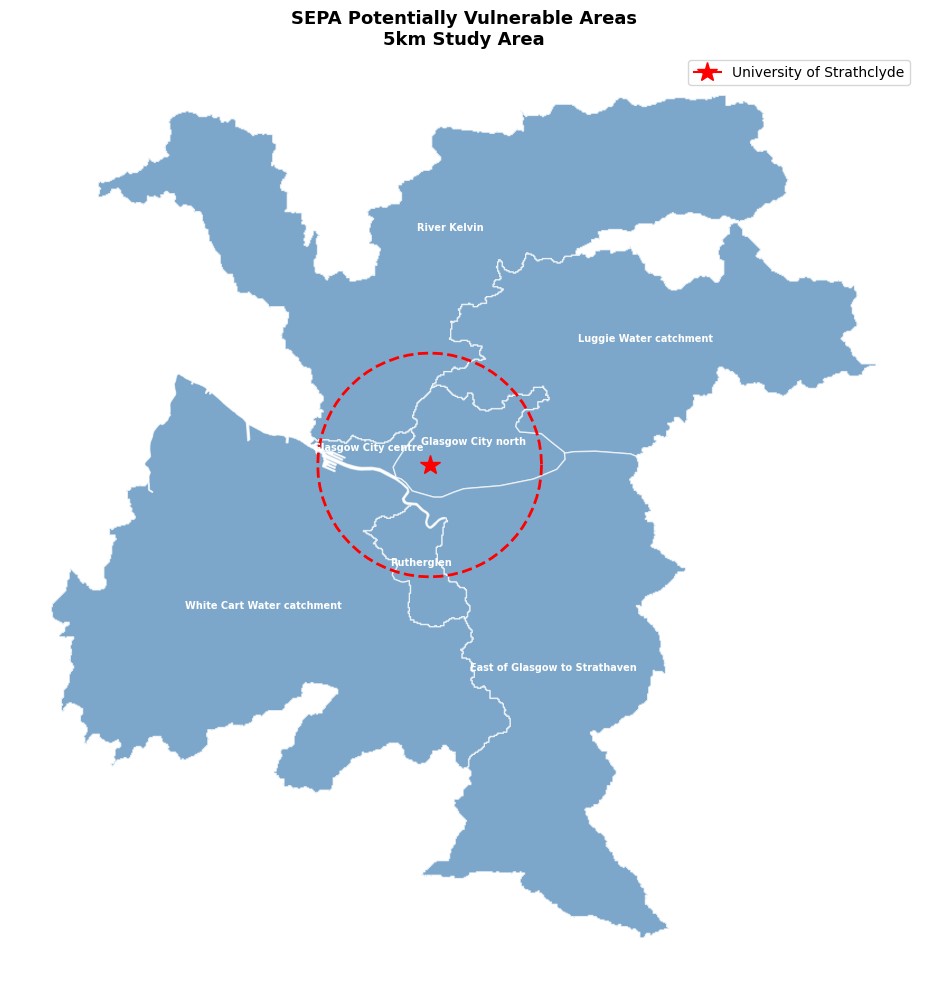

Map saved!


In [12]:
# SEPA PVA Map
uni_buffer = gpd.GeoDataFrame(
    geometry=[uni_point.buffer(RADIUS)], crs="EPSG:27700"
)

fig, ax = plt.subplots(figsize=(10, 10))

sepa_glasgow.plot(ax=ax, color='steelblue', edgecolor='white', alpha=0.7)
uni_buffer.plot(ax=ax, color='none', edgecolor='red', linewidth=2, linestyle='--')
ax.plot(UNI_X, UNI_Y, marker='*', color='red', markersize=15,
        label='University of Strathclyde')

for _, row in sepa_glasgow.iterrows():
    ax.annotate(row['PVA_Name'],
                xy=row['geometry'].centroid.coords[0],
                fontsize=7, ha='center', color='white', fontweight='bold')

ax.set_title("SEPA Potentially Vulnerable Areas\n5km Study Area",
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.legend()
plt.tight_layout()
plt.savefig(f"{MAPS_PATH}/eda_sepa_pva.png", dpi=150)
plt.show()
print("Map saved!")

In [13]:
# ============================================================
# 2.2 OSM BUILDINGS
# ============================================================

# Load buildings
buildings = gpd.read_file(OSM_BUILD)
print("Buildings loaded!")
print(f"Shape: {buildings.shape}")

Buildings loaded!
Shape: (55638, 7)


In [14]:
# Head
buildings.head(10)

,element,id,building,building:levels,height,name,geometry
0,node,1495513134,yes,None,None,The Hengler's Circus,POINT (258251.041 665933.24)
1,node,1705790482,yes,None,None,None,POINT (261171.756 663284.757)
2,node,1936303000,hotel,None,None,Fraser Suites,POINT (259568.006 664953.44)
3,node,2180409219,construction,None,None,Next,POINT (259150.854 665012.542)
4,node,2371954470,dormitory,None,None,Queen Margaret Halls,POINT (256448.68 668027.705)
5,node,2452854341,garage,None,None,None,POINT (261017.459 664194.037)
6,node,3218826826,university,None,None,Department of Theology & Religious Studies,POINT (256796.717 666714.266)
7,node,3813079919,commercial,None,None,Esso - Kelvinside,POINT (257520.079 667893.428)
8,node,5001302993,retail,None,None,Holland & Barrett,POINT (258752.96 665252.981)
9,node,5159005096,warehouse,None,None,Mammoet Ferry Transport (UK) BV,POINT (264035.06 661463.622)


In [15]:
# Info
buildings.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 55638 entries, 0 to 55637
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   element          55638 non-null  object  
 1   id               55638 non-null  int64   
 2   building         55638 non-null  object  
 3   building:levels  5588 non-null   object  
 4   height           259 non-null    object  
 5   name             1848 non-null   object  
 6   geometry         55638 non-null  geometry
dtypes: geometry(1), int64(1), object(5)
memory usage: 3.0+ MB


In [16]:
# Null check
print("Null values:")
print(buildings.isnull().sum())
print(f"\nTotal nulls: {buildings.isnull().sum().sum()}")
print(f"\nNull percentages:")
for col in buildings.columns:
    pct = buildings[col].isnull().sum() / len(buildings) * 100
    print(f"  {col:<20} {pct:.1f}%")

Null values:
element                0
id                     0
building               0
building:levels    50050
height             55379
name               53790
geometry               0
dtype: int64

Total nulls: 159219

Null percentages:
  element              0.0%
  id                   0.0%
  building             0.0%
  building:levels      90.0%
  height               99.5%
  name                 96.7%
  geometry             0.0%


In [17]:
# Describe
buildings.describe()

,id
count,5.563800e+04
mean,6.921145e+08
std,5.092448e+08
min,1.195100e+04
25%,2.081311e+08
50%,6.194767e+08
75%,1.210284e+09
max,1.328952e+10


In [18]:
# Building types value counts
print("Building types:")
print(buildings['building'].value_counts().head(15))

print(f"\nTotal unique types: {buildings['building'].nunique()}")
print(f"CRS: {buildings.crs}")

Building types:
building
yes                   28798
house                 10344
residential            6269
apartments             5427
semidetached_house     1141
terrace                 691
industrial              582
retail                  326
garage                  277
commercial              275
detached                168
roof                    166
office                  152
school                  142
university              141
Name: count, dtype: int64

Total unique types: 91
CRS: EPSG:27700


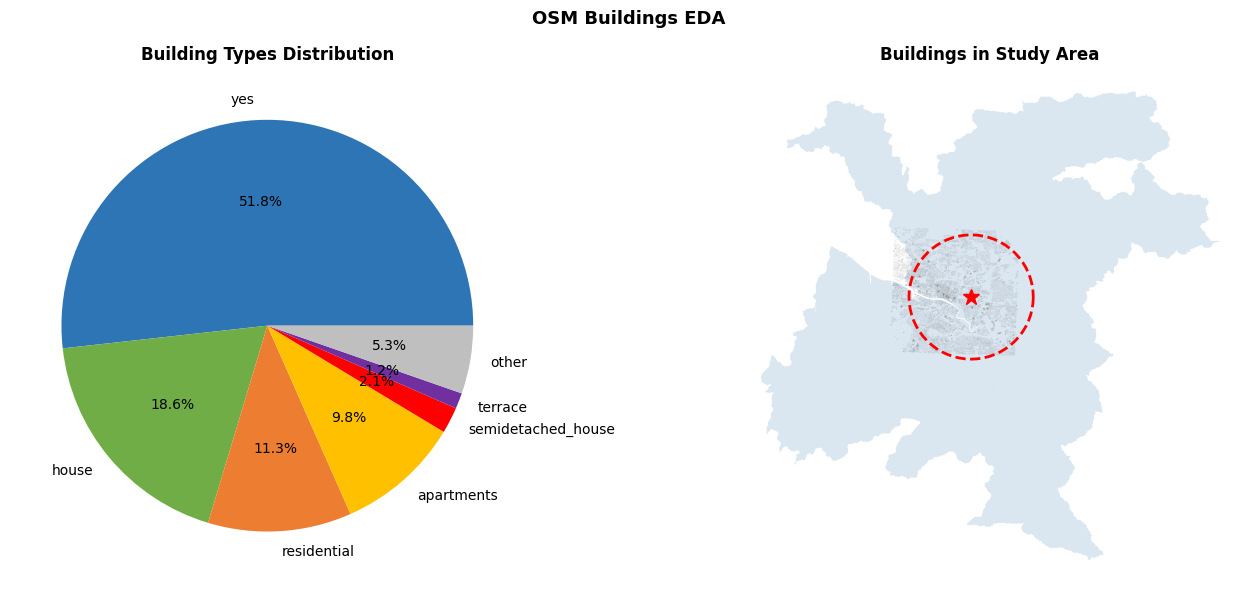

Saved!


In [19]:
# Buildings map
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Building types pie chart
top_types = buildings['building'].value_counts().head(6)
other = buildings['building'].value_counts()[6:].sum()
values = list(top_types.values) + [other]
labels = list(top_types.index) + ['other']

axes[0].pie(values, labels=labels, autopct='%1.1f%%',
            colors=['#2E75B6','#70AD47','#ED7D31',
                    '#FFC000','#FF0000','#7030A0','#BFBFBF'])
axes[0].set_title("Building Types Distribution", fontweight='bold')

# Right: Buildings map
sepa_glasgow.plot(ax=axes[1], color='steelblue', alpha=0.2)
buildings.plot(ax=axes[1], color='grey', markersize=0.5, alpha=0.5)
uni_buffer.plot(ax=axes[1], color='none', edgecolor='red',
                linewidth=2, linestyle='--')
axes[1].plot(UNI_X, UNI_Y, marker='*', color='red', markersize=12)
axes[1].set_title("Buildings in Study Area", fontweight='bold')
axes[1].axis('off')

plt.suptitle("OSM Buildings EDA", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{MAPS_PATH}/eda_buildings.png", dpi=150)
plt.show()
print("Saved!")

In [20]:
# ============================================================
# 2.3 OSM ROADS
# ============================================================

# Load roads
roads = gpd.read_file(OSM_ROADS)
print("Roads loaded!")
print(f"Shape: {roads.shape}")

Roads loaded!
Shape: (38218, 5)


In [21]:
# Head
roads.head()

,element,id,highway,name,geometry
0,node,194815,motorway_junction,Bothwell Street Interchange,POINT (257999.408 665090.116)
1,node,194816,motorway_junction,St George's Cross,POINT (257950.826 666001.954)
2,node,194825,motorway_junction,Townhead Interchange,POINT (260023.156 666227.352)
3,node,194829,motorway_junction,Blochairn,POINT (261052.051 665913.363)
4,node,352856,traffic_signals,None,POINT (264127.527 662433.314)


In [22]:
# Info
roads.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 38218 entries, 0 to 38217
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   element   38218 non-null  object  
 1   id        38218 non-null  int64   
 2   highway   38218 non-null  object  
 3   name      11654 non-null  object  
 4   geometry  38218 non-null  geometry
dtypes: geometry(1), int64(1), object(3)
memory usage: 1.5+ MB


In [23]:
roads.describe()

,id
count,3.821800e+04
mean,1.682052e+09
std,3.163721e+09
min,1.735000e+03
25%,1.339056e+08
50%,7.384824e+08
75%,1.313047e+09
max,1.395951e+10


In [24]:
# Null check
print("Null values:")
print(roads.isnull().sum())
print(f"\nTotal nulls: {roads.isnull().sum().sum()}")
print(f"\nNull percentages:")
for col in roads.columns:
    pct = roads[col].isnull().sum() / len(roads) * 100
    print(f"  {col:<10} {pct:.1f}%")

Null values:
element         0
id              0
highway         0
name        26564
geometry        0
dtype: int64

Total nulls: 26564

Null percentages:
  element    0.0%
  id         0.0%
  highway    0.0%
  name       69.5%
  geometry   0.0%


In [25]:
# Road types
print("Highway types:")
print(roads['highway'].value_counts().head(15))

print(f"\nTotal unique types: {roads['highway'].nunique()}")
print(f"CRS: {roads.crs}")

Highway types:
highway
footway            9437
service            7927
residential        5133
crossing           2274
steps              1989
bus_stop           1967
unclassified       1260
street_lamp        1101
tertiary           1005
cycleway            992
primary             982
traffic_signals     899
path                758
pedestrian          585
secondary           444
Name: count, dtype: int64

Total unique types: 37
CRS: EPSG:27700


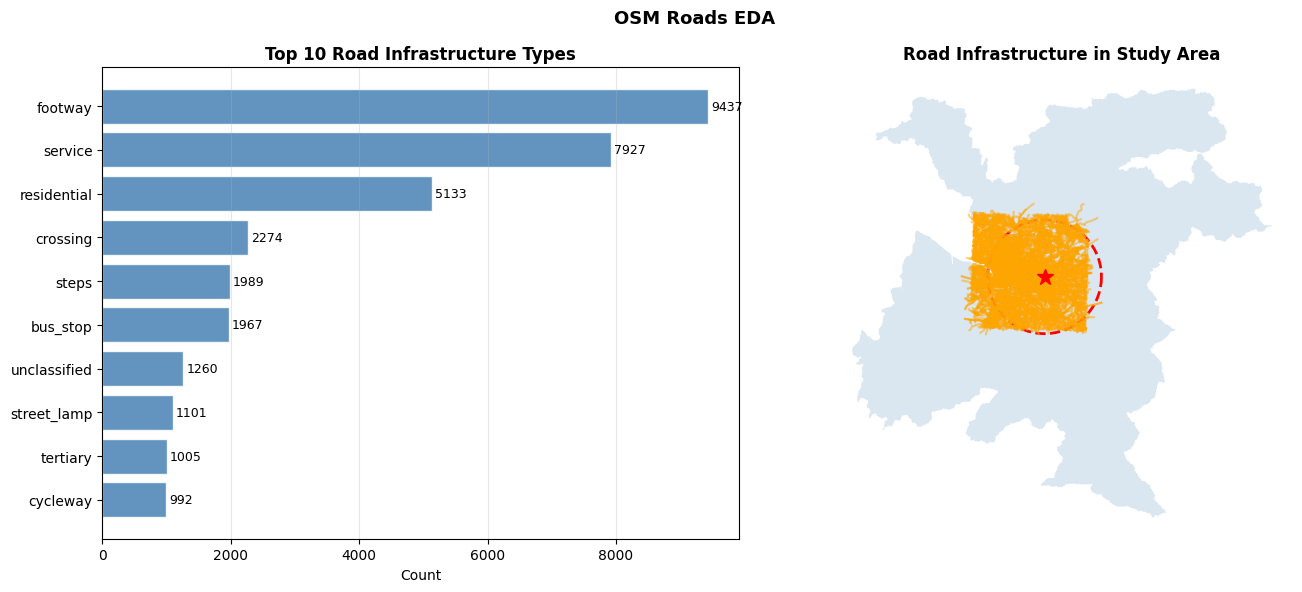

Saved!


In [26]:
# Roads map
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Road types bar chart
top_roads = roads['highway'].value_counts().head(10)
axes[0].barh(top_roads.index[::-1], top_roads.values[::-1],
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel("Count")
axes[0].set_title("Top 10 Road Infrastructure Types", fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(top_roads.values[::-1]):
    axes[0].text(v + 50, i, str(v), va='center', fontsize=9)

# Right: Roads map
sepa_glasgow.plot(ax=axes[1], color='steelblue', alpha=0.2)
roads.plot(ax=axes[1], color='orange', markersize=0.5, alpha=0.5)
uni_buffer.plot(ax=axes[1], color='none', edgecolor='red',
                linewidth=2, linestyle='--')
axes[1].plot(UNI_X, UNI_Y, marker='*', color='red', markersize=12)
axes[1].set_title("Road Infrastructure in Study Area", fontweight='bold')
axes[1].axis('off')

plt.suptitle("OSM Roads EDA", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{MAPS_PATH}/eda_roads.png", dpi=150)
plt.show()
print("Saved!")

In [27]:
# ============================================================
# 2.4 OSM WATER BODIES
# ============================================================

# Load water
water = gpd.read_file(OSM_WATER)
print("Water bodies loaded!")
print(f"Shape: {water.shape}")

Water bodies loaded!
Shape: (195, 4)


In [28]:
# Load water
water = gpd.read_file(OSM_WATER)
print("Water bodies loaded!")
print(f"Shape: {water.shape}")

Water bodies loaded!
Shape: (195, 4)


In [29]:
water.head()

,element,id,name,geometry
0,relation,919880,Nature Pond,"POLYGON ((257674.475 662316.729, 257677.239 66..."
1,relation,1230156,Hogganfield Loch,"POLYGON ((263898.758 667143.583, 263892.042 66..."
2,relation,1235452,None,"POLYGON ((261119.752 668741.567, 261131.394 66..."
3,relation,1235453,None,"POLYGON ((260913.581 668768.335, 260924.731 66..."
4,relation,1288901,River Clyde,"POLYGON ((268768.649 659687.368, 268781.771 65..."


In [30]:
# Info
water.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   element   195 non-null    object  
 1   id        195 non-null    int64   
 2   name      34 non-null     object  
 3   geometry  195 non-null    geometry
dtypes: geometry(1), int64(1), object(2)
memory usage: 6.2+ KB


In [31]:
# Null check
print("Null values:")
print(water.isnull().sum())
print(f"\nTotal nulls: {water.isnull().sum().sum()}")
print(f"\nNull percentages:")
for col in water.columns:
    pct = water[col].isnull().sum() / len(water) * 100
    print(f"  {col:<10} {pct:.1f}%")

Null values:
element       0
id            0
name        161
geometry      0
dtype: int64

Total nulls: 161

Null percentages:
  element    0.0%
  id         0.0%
  name       82.6%
  geometry   0.0%


In [32]:
# Filter just River Clyde
clyde = water[water['name'] == 'River Clyde']
print(f"Clyde polygons: {len(clyde)}")

Clyde polygons: 3


In [34]:
# Merge Clyde polygons into one shape
from shapely.ops import unary_union

clyde_union = clyde.geometry.union_all()
print(f"Clyde merged into single geometry: {clyde_union.geom_type}")
print(f"Clyde area: {clyde_union.area/10000:.1f} hectares")

# Calculate distance from elevation points sample to Clyde
# Test on first 5 points
sample = elevation.head(5).copy()
sample['dist_to_clyde'] = sample.geometry.distance(clyde_union)
print(f"\nSample distances to River Clyde:")
print(sample[['elevation', 'dist_to_clyde']])

Clyde merged into single geometry: Polygon
Clyde area: 217.7 hectares


NameError: name 'elevation' is not defined

In [ ]:
# Load feature matrix and add dist_to_clyde
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from shapely.ops import unary_union

# Load existing feature matrix
feature_matrix = pd.read_csv(FEATURE_CSV)
print(f"Feature matrix loaded: {feature_matrix.shape}")
print(feature_matrix.head())

Feature matrix loaded: (7843, 6)
   elevation  dist_to_water  building_count  road_count  rainfall_annual  \
0          8     429.130538              62          57         3.485306   
1         17     808.615363              42          58         3.485306   
2         14     724.363088              38          73         3.485306   
3         13     644.627770              37          72         3.485306   
4         12     571.303806              44          71         3.485306   

   flood_risk  
0           2  
1           1  
2           2  
3           2  
4           2  


In [ ]:
# Recreate grid with geometry
UNI_X, UNI_Y, RADIUS = 260983, 665006, 5000
uni_point = Point(UNI_X, UNI_Y)

x_coords = np.arange(UNI_X - RADIUS, UNI_X + RADIUS, 100)
y_coords = np.arange(UNI_Y - RADIUS, UNI_Y + RADIUS, 100)

grid_points = [Point(x, y) for x in x_coords for y in y_coords
               if Point(x, y).distance(uni_point) <= RADIUS]

grid = gpd.GeoDataFrame(
    {'grid_id': range(len(grid_points))},
    geometry=grid_points,
    crs="EPSG:27700"
)

print(f"Grid recreated: {len(grid):,} points")

Grid recreated: 7,843 points


In [ ]:
# Calculate distance to River Clyde for all grid points
print("Calculating distance to River Clyde...")
print("This takes about 1 minute...")

grid['dist_to_clyde'] = grid.geometry.distance(clyde_union)

print(f"Done!")
print(f"\nDistance to Clyde statistics (metres):")
print(f"  Min:  {grid['dist_to_clyde'].min():.1f}m")
print(f"  Max:  {grid['dist_to_clyde'].max():.1f}m")
print(f"  Mean: {grid['dist_to_clyde'].mean():.1f}m")
print(f"  Std:  {grid['dist_to_clyde'].std():.1f}m")
print(f"\nPoints within 500m of Clyde: {(grid['dist_to_clyde']<=500).sum():,}")
print(f"Points within 200m of Clyde: {(grid['dist_to_clyde']<=200).sum():,}")

Calculating distance to River Clyde...
This takes about 1 minute...
Done!

Distance to Clyde statistics (metres):
  Min:  0.0m
  Max:  6161.5m
  Mean: 2094.6m
  Std:  1566.9m

Points within 500m of Clyde: 1,368
Points within 200m of Clyde: 651


In [ ]:
# Add dist_to_clyde to feature matrix
feature_matrix['dist_to_clyde'] = grid['dist_to_clyde'].values

print("Updated feature matrix:")
print(f"Shape: {feature_matrix.shape}")
print(f"\nColumns: {feature_matrix.columns.tolist()}")
print(f"\nDist to Clyde stats:")
print(f"  Min:  {feature_matrix['dist_to_clyde'].min():.1f}m")
print(f"  Max:  {feature_matrix['dist_to_clyde'].max():.1f}m")
print(f"  Mean: {feature_matrix['dist_to_clyde'].mean():.1f}m")
print(f"  Nulls: {feature_matrix['dist_to_clyde'].isnull().sum()}")

# Save updated feature matrix
feature_matrix.to_csv(FEATURE_CSV, index=False)
print(f"\nSaved to: {FEATURE_CSV}")

Updated feature matrix:
Shape: (7843, 7)

Columns: ['elevation', 'dist_to_water', 'building_count', 'road_count', 'rainfall_annual', 'flood_risk', 'dist_to_clyde']

Dist to Clyde stats:
  Min:  0.0m
  Max:  6161.5m
  Mean: 2094.6m
  Nulls: 0

Saved to: /Users/riteshghorpade/Documents/010_Project/002_Dataset/feature_matrix.csv


In [ ]:
# Check correlation of new feature with flood risk
corr = feature_matrix.corr()['flood_risk'].sort_values()

print("Updated correlation with flood_risk:")
print("=" * 40)
for feat, val in corr.items():
    if feat != 'flood_risk':
        print(f"  {feat:<20} {val:>7.3f}")

Updated correlation with flood_risk:
  elevation             -0.807
  dist_to_clyde         -0.741
  rainfall_annual       -0.467
  dist_to_water         -0.284
  building_count        -0.072
  road_count             0.198


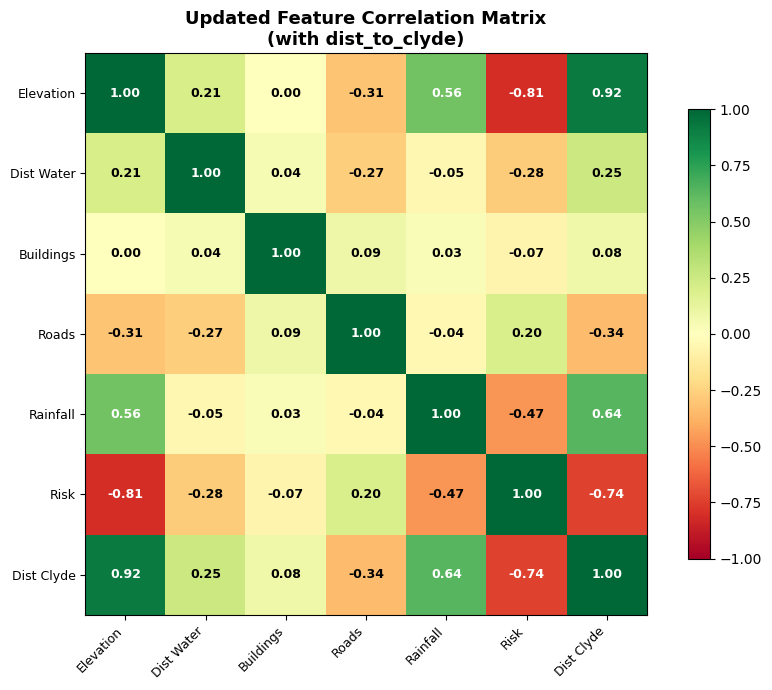

Saved!


In [ ]:
# Updated correlation heatmap
import matplotlib.pyplot as plt
import numpy as np

corr = feature_matrix.corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8)

labels = ['Elevation', 'Dist Water', 'Buildings',
          'Roads', 'Rainfall', 'Risk', 'Dist Clyde']
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(labels, fontsize=9)

for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}",
                ha='center', va='center', fontsize=9,
                fontweight='bold',
                color='white' if abs(corr.iloc[i,j]) > 0.5 else 'black')

ax.set_title("Updated Feature Correlation Matrix\n(with dist_to_clyde)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{MAPS_PATH}/correlation_matrix_updated.png", dpi=150)
plt.show()
print("Saved!")

In [ ]:
# Named water bodies and key stats
print("Named water bodies:")
print(water['name'].value_counts().head(10))

print(f"\nTotal named:   {water['name'].notna().sum()}")
print(f"Total unnamed: {water['name'].isna().sum()}")
print(f"\nGeometry type: {water.geometry.geom_type.unique()}")
print(f"CRS: {water.crs}")

# Calculate water body areas
water['area_m2'] = water.geometry.area
print(f"\nWater body areas (m2):")
print(f"  Min:  {water['area_m2'].min():.1f}")
print(f"  Max:  {water['area_m2'].max():.1f}")
print(f"  Mean: {water['area_m2'].mean():.1f}")

Named water bodies:
name
Rainwater Collection Butt    7
River Kelvin                 6
River Clyde                  3
Nature Pond                  2
Pinkston Basin               2
Bingham's Pond               1
Possil Loch                  1
Model Boat Pond              1
Firhill Basin                1
Hogganfield Loch             1
Name: count, dtype: int64

Total named:   34
Total unnamed: 161

Geometry type: ['Polygon']
CRS: EPSG:27700

Water body areas (m2):
  Min:  0.4
  Max:  1394203.2
  Mean: 16762.8


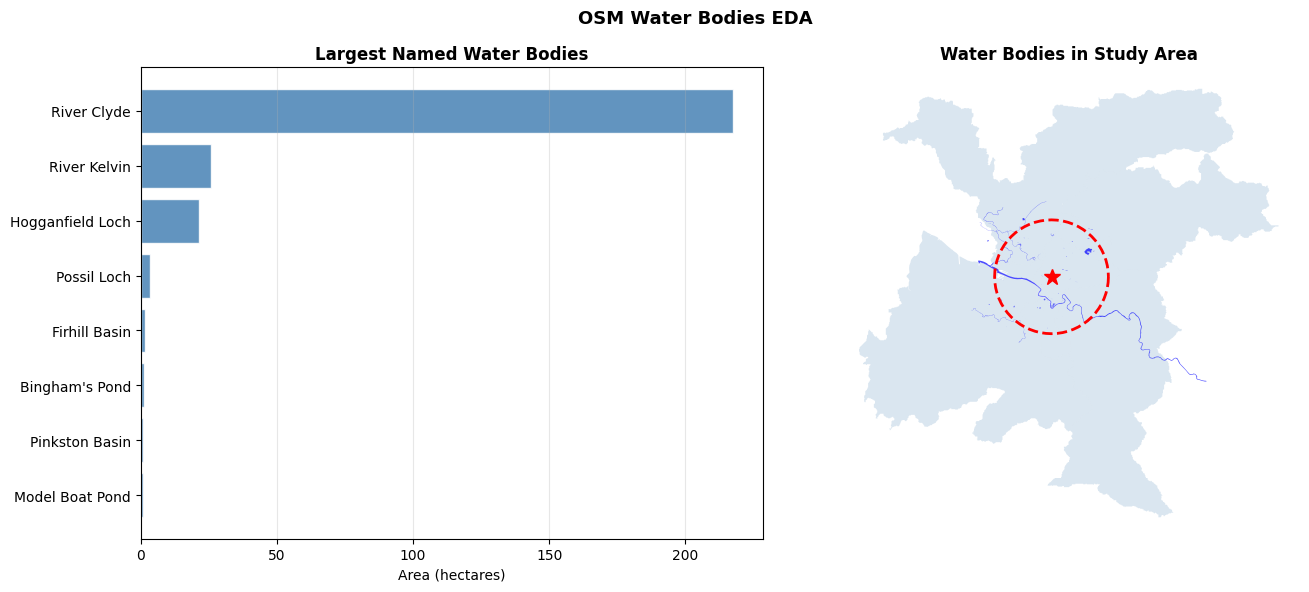

Saved!


In [ ]:
# Water bodies map
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Area distribution
water_named = water[water['name'].notna()].copy()
water_named['area_ha'] = water_named['area_m2'] / 10000
top_water = water_named.groupby('name')['area_ha'].sum().sort_values(ascending=False).head(8)

axes[0].barh(top_water.index[::-1], top_water.values[::-1],
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel("Area (hectares)")
axes[0].set_title("Largest Named Water Bodies", fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Right: Water bodies map
sepa_glasgow.plot(ax=axes[1], color='steelblue', alpha=0.2)
water.plot(ax=axes[1], color='blue', alpha=0.7)
uni_buffer.plot(ax=axes[1], color='none', edgecolor='red',
                linewidth=2, linestyle='--')
axes[1].plot(UNI_X, UNI_Y, marker='*', color='red', markersize=12)
axes[1].set_title("Water Bodies in Study Area", fontweight='bold')
axes[1].axis('off')

plt.suptitle("OSM Water Bodies EDA", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{MAPS_PATH}/eda_water.png", dpi=150)
plt.show()
print("Saved!")

In [ ]:
# ============================================================
# 2.5 NASA SRTM ELEVATION
# ============================================================

# Load elevation
elevation = gpd.read_file(NASA_ELEV)
print("Elevation loaded!")
print(f"Shape: {elevation.shape}")

Elevation loaded!
Shape: (259200, 4)


In [ ]:
# Head
elevation.head()

,latitude,longitude,elevation,geometry
0,55.92,-4.350000,79,POINT (253242.407 672152.61)
1,55.92,-4.349722,79,POINT (253259.762 672152.02)
2,55.92,-4.349444,79,POINT (253277.118 672151.43)
3,55.92,-4.349167,79,POINT (253294.473 672150.84)
4,55.92,-4.348889,78,POINT (253311.828 672150.251)


In [ ]:
# Info
elevation.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 259200 entries, 0 to 259199
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype   
---  ------     --------------   -----   
 0   latitude   259200 non-null  float64 
 1   longitude  259200 non-null  float64 
 2   elevation  259200 non-null  int16   
 3   geometry   259200 non-null  geometry
dtypes: float64(2), geometry(1), int16(1)
memory usage: 6.4 MB


In [ ]:
# Null check
print("Null values:")
print(elevation.isnull().sum())
print(f"\nTotal nulls: {elevation.isnull().sum().sum()}")
print(f"CRS: {elevation.crs}")

Null values:
latitude     0
longitude    0
elevation    0
geometry     0
dtype: int64

Total nulls: 0
CRS: EPSG:27700


In [ ]:
# Describe elevation column
print("Elevation statistics (metres):")
print(elevation['elevation'].describe())

Elevation statistics (metres):
count    259200.000000
mean         41.585606
std          25.756288
min         -23.000000
25%          20.000000
50%          35.000000
75%          62.000000
max         132.000000
Name: elevation, dtype: float64


In [ ]:
# Key statistics
print("Key elevation insights:")
print(f"  Range:              {elevation['elevation'].min()}m to {elevation['elevation'].max()}m")
print(f"  Mean:               {elevation['elevation'].mean():.1f}m")
print(f"  Median:             {elevation['elevation'].median():.1f}m")
print(f"  Std:                {elevation['elevation'].std():.1f}m")
print(f"\n  Below sea level:    {(elevation['elevation']<0).sum():,} points")
print(f"  Below 10m:          {(elevation['elevation']<=10).sum():,} points ({(elevation['elevation']<=10).sum()/len(elevation)*100:.1f}%)")
print(f"  Below 15m (High risk threshold): {(elevation['elevation']<=15).sum():,} points ({(elevation['elevation']<=15).sum()/len(elevation)*100:.1f}%)")
print(f"  Below 35m (Medium risk threshold): {(elevation['elevation']<=35).sum():,} points ({(elevation['elevation']<=35).sum()/len(elevation)*100:.1f}%)")
print(f"  Above 35m (Low risk): {(elevation['elevation']>35).sum():,} points ({(elevation['elevation']>35).sum()/len(elevation)*100:.1f}%)")

Key elevation insights:
  Range:              -23m to 132m
  Mean:               41.6m
  Median:             35.0m
  Std:                25.8m

  Below sea level:    282 points
  Below 10m:          23,720 points (9.2%)
  Below 15m (High risk threshold): 45,167 points (17.4%)
  Below 35m (Medium risk threshold): 130,188 points (50.2%)
  Above 35m (Low risk): 129,012 points (49.8%)


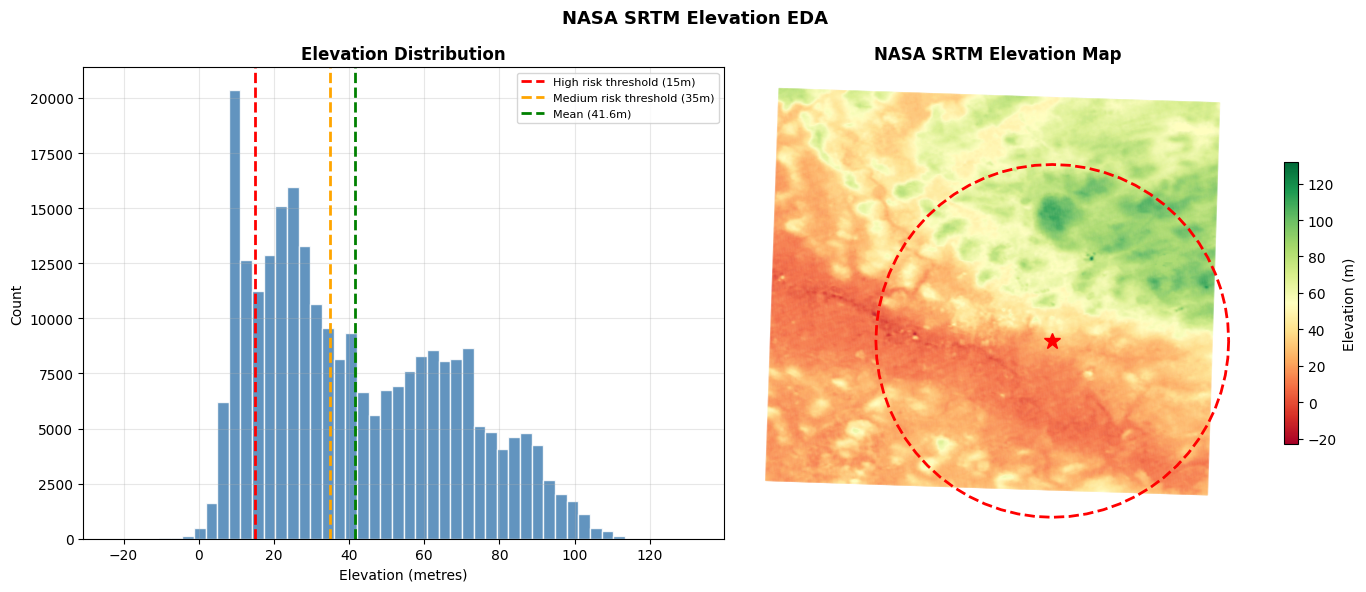

Saved!


In [ ]:
# Elevation visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Histogram
axes[0].hist(elevation['elevation'], bins=50,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(15, color='red', linestyle='--',
                linewidth=2, label='High risk threshold (15m)')
axes[0].axvline(35, color='orange', linestyle='--',
                linewidth=2, label='Medium risk threshold (35m)')
axes[0].axvline(elevation['elevation'].mean(), color='green',
                linestyle='--', linewidth=2,
                label=f"Mean ({elevation['elevation'].mean():.1f}m)")
axes[0].set_xlabel("Elevation (metres)")
axes[0].set_ylabel("Count")
axes[0].set_title("Elevation Distribution", fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Right: Elevation map
elevation.plot(column='elevation', ax=axes[1],
               cmap='RdYlGn', markersize=0.1, alpha=0.7,
               legend=True,
               legend_kwds={'label': 'Elevation (m)', 'shrink': 0.6})
uni_buffer.plot(ax=axes[1], color='none', edgecolor='red',
                linewidth=2, linestyle='--')
axes[1].plot(UNI_X, UNI_Y, marker='*', color='red', markersize=12)
axes[1].set_title("NASA SRTM Elevation Map", fontweight='bold')
axes[1].axis('off')

plt.suptitle("NASA SRTM Elevation EDA", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{MAPS_PATH}/eda_elevation.png", dpi=150)
plt.show()
print("Saved!")

In [ ]:
# ============================================================
# 2.6 HADUK-GRID RAINFALL
# ============================================================

# Load daily rainfall
df_rain = pd.read_csv(RAIN_DAILY)
df_rain['date'] = pd.to_datetime(df_rain['date'])
print("HadUK-Grid daily rainfall loaded!")
print(f"Shape: {df_rain.shape}")

HadUK-Grid daily rainfall loaded!
Shape: (4384, 10)


In [ ]:
# Head
df_rain.head(10)

NameError: name 'df_rain' is not defined

In [ ]:
# Info
df_rain.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4384 entries, 0 to 4383
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             4384 non-null   datetime64[ns]
 1   year             4384 non-null   int64         
 2   month            4384 non-null   int64         
 3   day              4384 non-null   int64         
 4   x_bng            4384 non-null   float64       
 5   y_bng            4384 non-null   float64       
 6   latitude         4384 non-null   float64       
 7   longitude        4384 non-null   float64       
 8   dist_from_uni_m  4384 non-null   float64       
 9   rainfall_mm      4384 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int64(3)
memory usage: 342.6 KB


In [ ]:
# Null check
print("Null values:")
print(df_rain.isnull().sum())
print(f"\nTotal nulls: {df_rain.isnull().sum().sum()}")

Null values:
date               0
year               0
month              0
day                0
x_bng              0
y_bng              0
latitude           0
longitude          0
dist_from_uni_m    0
rainfall_mm        0
dtype: int64

Total nulls: 0


In [ ]:
# Describe
df_rain.describe()

,date,year,month,day,x_bng,y_bng,latitude,longitude,dist_from_uni_m,rainfall_mm
count,4384,4384.000000,4384.000000,4384.000000,4384.000000,4384.000000,4384.000000,4384.000000,4384.000000,4384.000000
mean,2024-07-01 12:00:00,2024.000000,6.521898,15.732664,260000.000000,665000.000000,55.857853,-4.236973,3605.801844,2.837666
min,2023-01-01 00:00:00,2023.000000,1.000000,1.000000,257500.000000,662500.000000,55.834680,-4.278198,2919.130864,0.000000
25%,2023-10-01 18:00:00,2023.000000,4.000000,8.000000,257500.000000,662500.000000,55.835768,-4.276228,2926.825117,0.008738
50%,2024-07-01 12:00:00,2024.000000,7.000000,16.000000,260000.000000,665000.000000,55.857852,-4.236950,3606.617260,0.618609
75%,2025-04-01 06:00:00,2025.000000,10.000000,23.000000,262500.000000,667500.000000,55.879937,-4.197695,4285.593987,3.930632
max,2025-12-31 00:00:00,2025.000000,12.000000,31.000000,262500.000000,667500.000000,55.881027,-4.195793,4290.841992,39.457835
std,NaN,0.816217,3.449380,8.802374,2500.285177,2500.285177,0.022462,0.039937,681.633365,4.614444


In [ ]:
# Key rainfall statistics
print("Key rainfall insights:")
print(f"  Date range:         {df_rain['date'].min().date()} to {df_rain['date'].max().date()}")
print(f"  Years:              {sorted(df_rain['year'].unique())}")
print(f"  Grid cells:         {df_rain.groupby(['x_bng','y_bng']).ngroups}")
print(f"  Total days:         {df_rain['date'].nunique()}")

print(f"\n  Daily rainfall (mm):")
print(f"    Min:    {df_rain['rainfall_mm'].min():.3f}")
print(f"    Max:    {df_rain['rainfall_mm'].max():.3f}")
print(f"    Mean:   {df_rain['rainfall_mm'].mean():.3f}")
print(f"    Std:    {df_rain['rainfall_mm'].std():.3f}")

print(f"\n  Dry days (<1mm):    {(df_rain['rainfall_mm']<1).sum():,} ({(df_rain['rainfall_mm']<1).sum()/len(df_rain)*100:.1f}%)")
print(f"  Wet days (>=1mm):   {(df_rain['rainfall_mm']>=1).sum():,} ({(df_rain['rainfall_mm']>=1).sum()/len(df_rain)*100:.1f}%)")
print(f"  Heavy days (>=10mm):{(df_rain['rainfall_mm']>=10).sum():,} ({(df_rain['rainfall_mm']>=10).sum()/len(df_rain)*100:.1f}%)")

print(f"\n  Monthly averages (mm/day):")
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
for i, m in enumerate(months, 1):
    avg = df_rain[df_rain['month']==i]['rainfall_mm'].mean()
    print(f"    {m}: {avg:.3f}")

Key rainfall insights:
  Date range:         2023-01-01 to 2025-12-31
  Years:              [np.int64(2023), np.int64(2024), np.int64(2025)]
  Grid cells:         4
  Total days:         1096

  Daily rainfall (mm):
    Min:    0.000
    Max:    39.458
    Mean:   2.838
    Std:    4.614

  Dry days (<1mm):    2,424 (55.3%)
  Wet days (>=1mm):   1,960 (44.7%)
  Heavy days (>=10mm):362 (8.3%)

  Monthly averages (mm/day):
    Jan: 3.036
    Feb: 2.380
    Mar: 2.488
    Apr: 2.186
    May: 2.327
    Jun: 2.041
    Jul: 2.826
    Aug: 3.200
    Sep: 3.020
    Oct: 3.320
    Nov: 2.847
    Dec: 4.300


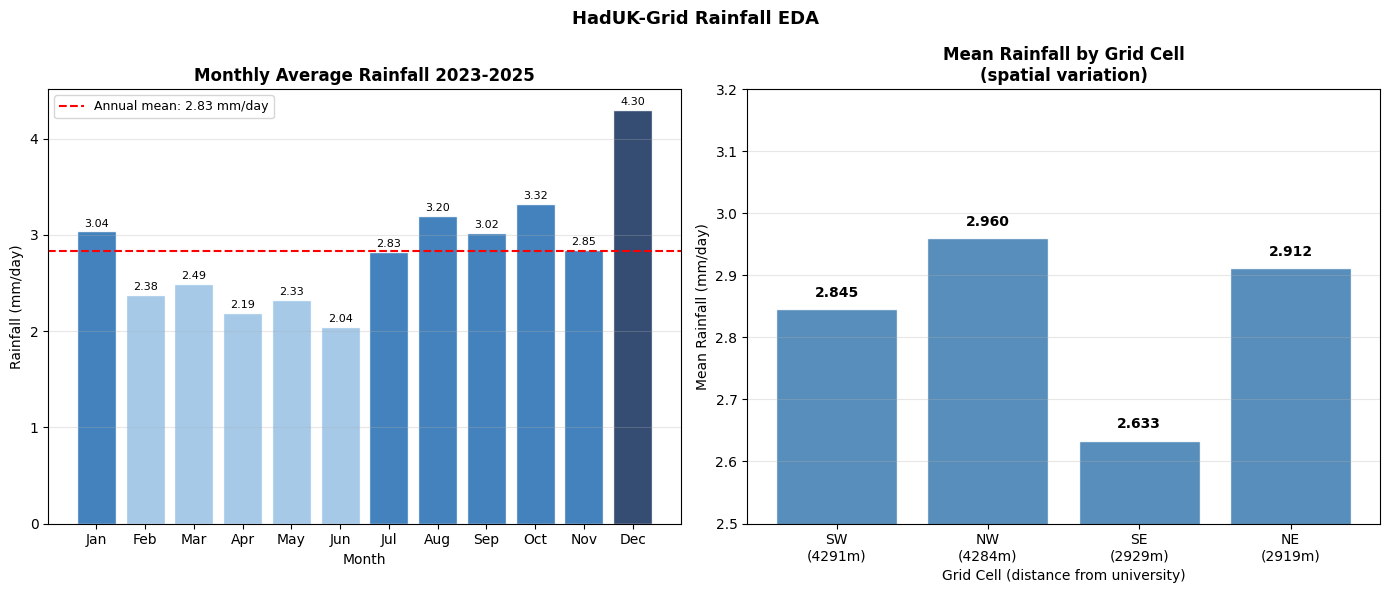

Saved!


In [ ]:
# Rainfall visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Monthly average bar chart
months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']
monthly_avg = [df_rain[df_rain['month']==i]['rainfall_mm'].mean()
               for i in range(1,13)]

colors = ['#1F3864' if v >= 3.5 else '#2E75B6' if v >= 2.5 else '#9DC3E6'
          for v in monthly_avg]
axes[0].bar(months, monthly_avg, color=colors,
            edgecolor='white', alpha=0.9)
axes[0].axhline(y=sum(monthly_avg)/12, color='red',
                linestyle='--', linewidth=1.5,
                label=f"Annual mean: {sum(monthly_avg)/12:.2f} mm/day")
for i, v in enumerate(monthly_avg):
    axes[0].text(i, v + 0.05, f"{v:.2f}",
                 ha='center', fontsize=8)
axes[0].set_title("Monthly Average Rainfall 2023-2025",
                  fontweight='bold')
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Rainfall (mm/day)")
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Right: Spatial variation across 4 grid cells
cell_means = df_rain.groupby(['x_bng','y_bng'])['rainfall_mm'].mean()
cell_labels = ['SW\n(4291m)', 'NW\n(4284m)',
               'SE\n(2929m)', 'NE\n(2919m)']
axes[1].bar(cell_labels, cell_means.values,
            color='steelblue', edgecolor='white', alpha=0.9)
for i, v in enumerate(cell_means.values):
    axes[1].text(i, v + 0.02, f"{v:.3f}",
                 ha='center', fontsize=10, fontweight='bold')
axes[1].set_title("Mean Rainfall by Grid Cell\n(spatial variation)",
                  fontweight='bold')
axes[1].set_xlabel("Grid Cell (distance from university)")
axes[1].set_ylabel("Mean Rainfall (mm/day)")
axes[1].set_ylim(2.5, 3.2)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle("HadUK-Grid Rainfall EDA", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{MAPS_PATH}/eda_rainfall_final.png", dpi=150)
plt.show()
print("Saved!")

In [ ]:
# Filter just River Clyde
clyde = water[water['name'] == 'River Clyde']
print(f"Clyde polygons: {len(clyde)}")

Clyde polygons: 3
